In [45]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import os

import pygraphviz
from scipy.cluster import hierarchy
from pathlib import Path
from scipy import stats
from statsmodels.stats.multitest import multipletests
from networkx.drawing.nx_agraph import graphviz_layout
from matplotlib.colors import ListedColormap
from networkx import spring_layout



In [46]:

# Define function: data loading and validation
def load_and_validate_data(file_path, test):
    """
    Load cell-correlation CSV data and validate format integrity:
    - First row/column are cell IDs (starting from 0, contiguous numbering)
    - Data matrix must be square (same number of rows and columns)
    """
    try:
        # Read CSV (first column as index = cell IDs, first row as column names = cell IDs)
        data = pd.read_csv(file_path, header=0, index_col=0)

        # Basic validation: ensure data is not empty
        if data.empty:
            raise ValueError("Data is empty. Please check CSV file content.")
        if test == 'test1':
            celltype_info = data['celltype']
            data = data.drop(columns='celltype')
        
        # Extract cell IDs and cast to int (ensure ID format is valid)
        row_ids = data.index.values  # Row IDs (first column)
        col_ids = data.columns.values  # Column IDs (first row)
        if row_ids.dtype !=np.float64 or col_ids.dtype !=np.float64:
            row_ids = [float(i) for i in range(len(row_ids))]
            col_ids = [float(i) for i in range(len(col_ids))]
        try:
                row_ids_int = np.array(row_ids, dtype=np.float64).round().astype(int)
                col_ids_int = np.array(col_ids, dtype=np.float64).round().astype(int)
        except ValueError:
                raise ValueError("Cell IDs must be numeric (integers or float values convertible to integers).")
        # Critical validation: row/column IDs must match and matrix must be square
        if data.shape[0] != data.shape[1]:
            raise ValueError(f"Correlation matrix must be square; current shape is {data.shape[0]}x{data.shape[1]}.")

        # Validation passed, return results
        if VERBOSE:
            print(f"✅ Data loaded successfully: {len(row_ids)} cells, matrix shape {data.shape[0]}x{data.shape[1]}")
        if test == 'test1':
            return data, (row_ids, celltype_info)
        else:
            return data, row_ids  # data=correlation matrix, row_ids=cell ID list

    except Exception as e:
        print(f"❌ Data loading failed: {str(e)}")
        raise  # Re-raise error for easier debugging



In [47]:

# %%
# Define function: significance filtering and mask generation (abstract method)
def select_significant(data, alpha, threshold):
    # Extract upper-triangular data (avoid duplicate computation)
    upper_triangle_indices = np.triu_indices_from(data, k=1)
    linear_data = data.values[upper_triangle_indices]
    
    # Significance test (Z-score + p-value)
    z_scores = stats.zscore(linear_data)
    p_values = stats.norm.sf(z_scores)  # Right-tail p-value
    print(f"p-value range: {min(p_values):.4f} - {max(p_values):.4f}")
    if min(p_values) > alpha:
        print("[Fallback] increasing p due to low significnace")
        alpha += 0.01
    # Significance mask
    mask = p_values < alpha 
    print(f'smallest value < p{alpha}: {np.nanmin(linear_data[mask]) if mask.any() else "N/A"}')


    # Threshold mask
    # mask = np.zeros_like(sig_mask, dtype=bool)
    # if sig_mask.any():
    #     mask[sig_mask] = linear_data[sig_mask] > threshold
    # print(f'smallest value after thersholding: {np.nanmin(linear_data[mask]) if mask.any() else "N/A"}')
    # Generate 2D mask (keep only edges with correlation > threshold)
    avg_val = np.mean(linear_data[mask]) if mask.any() else 0
    print(f'average value of significant correlations: {avg_val:.4f}')
    mask_2d = np.zeros((data.shape[0], data.shape[0]), dtype=bool)
    mask_2d[np.triu_indices_from(data, k=1)] = mask
    mask_2d = mask_2d | mask_2d.T  # Symmetrize (undirected graph)
    
    return mask_2d, mask, avg_val, p_values



In [48]:

def select_threshold(data, threshold):
    # Extract upper-triangular data (avoid duplicate computation)
    upper_triangle_indices = np.triu_indices_from(data, k=1)
    linear_data = data.values[upper_triangle_indices]
    
    
    # Threshold mask
    selected_data = [i if i > threshold else 0 for i in linear_data]
    print(f'{np.sum(np.array(selected_data)!=0)} data are selected based on threshold {threshold}')

    print(selected_data)
    # Generate 2D mask (keep only edges with correlation > threshold)
    avg_val = np.mean(selected_data) if len(selected_data)!=0 else 0
    print(f'average value of significant correlations: {avg_val:.4f}')
    mask_2d = np.zeros((data.shape[0], data.shape[0]), dtype=bool)
    mask_2d[np.triu_indices_from(data, k=1)] = selected_data
    mask_2d = mask_2d | mask_2d.T  # Symmetrize (undirected graph)
    
    return mask_2d, selected_data, avg_val, None



In [49]:
# Define function: matrix binarization (abstract method)
def binarize_matrix(matrix, mask):
    """
    Binarize the correlation matrix:
    - correlation > threshold -> 1 (keep connection)
    - correlation <= threshold -> 0 (remove connection)
    - set diagonal to 0 (no self-connection)
    """
    if VERBOSE:
        print(f"\n⚙️  Binarizing matrix using significance values...")
    # Copy matrix to avoid modifying original data
    binary_matrix = matrix.copy()
    
    # Apply threshold
    binary_matrix[mask == True] = 1
    binary_matrix[mask == False] = 0
    
    # Set diagonal to 0 (self-connections are invalid)
    np.fill_diagonal(binary_matrix, 0)
    
    # Count valid edges (undirected graph: each edge counted twice, divide by 2)
    total_edges = int(np.sum(binary_matrix) / 2)
    if VERBOSE:
        print(f"✅ Binarization complete. Network contains {total_edges} valid edges")
    
    return binary_matrix


def weight_matrix(matrix, mask):
    """
    Binarize the correlation matrix:
    - correlation > threshold -> 1 (keep connection)
    - correlation <= threshold -> 0 (remove connection)
    - set diagonal to 0 (no self-connection)
    """
    if VERBOSE:
        print(f"\n⚙️  Binarizing matrix using significance values...")
    # Copy matrix to avoid modifying original data
    weight_matrix = matrix.copy()
    
    # Apply threshold
    weight_matrix[mask == False] = 0
    
    # Set diagonal to 0 (self-connections are invalid)
    np.fill_diagonal(weight_matrix, 0)
    
    # Count valid edges (undirected graph: each edge counted twice, divide by 2)
    total_edges = int(np.count_nonzero(weight_matrix) / 2)
    if VERBOSE:
        print(f"✅ Weighted-network extraction complete. Network contains {total_edges} valid edges")
    
    return weight_matrix


In [50]:

# Define function: network topology analysis (abstract method)
def analyze_network(adjacency_matrix, cell_ids):
    """
    Analyze network topology based on the adjacency matrix:
    - Node-level metrics: degree, clustering coefficient, betweenness centrality
    - Network-level metrics: number of connected components, characteristic path length of largest component
    """
    try:
        if VERBOSE:
            print("\n🔬 Starting network topology analysis...")
        
        # 1. Build an undirected graph (use cell IDs as node labels)
        G = nx.from_numpy_array(adjacency_matrix, create_using=nx.Graph())
        G = nx.relabel_nodes(G, {i: cell_id for i, cell_id in enumerate(range(len(cell_ids)))})
        
        # 2. Compute network-level metrics (global network properties)
        connected_components = list(nx.connected_components(G))  # All connected components
        num_components = len(connected_components)  # Number of connected components
        components_len = [len(c) for c in connected_components]
        component_map = {}  # Component-size mapping
        for comp_id, component in enumerate(connected_components):
            for node in component:
                component_map[node] = (comp_id, components_len[comp_id])

        # 3. Compute node-level metrics (per-cell properties)
        node_df = pd.DataFrame({
            "Cell_ID": list(G.nodes),
            "Clustering_Coefficient": list(nx.clustering(G).values()),  # Clustering coefficient
            "Degree": [deg for _, deg in G.degree()],  # Degree
            "Betweenness_Centrality": list(nx.betweenness_centrality(G).values()),  # Betweenness centrality
            "Component": [component_map[node][0] for node in G.nodes],
            "Component_length": [component_map[node][1] for node in G.nodes]  # Size of belonging connected component
        })
        
        # Largest connected-component info
        max_comp_nodes = max(connected_components, key=len) if connected_components else []
        
        # Aggregate network-level metrics
        network_df = pd.DataFrame([{
            "Total_Nodes": G.number_of_nodes(),
            "Total_Edges": G.number_of_edges(),
            "Total_Components": num_components,
            "Components_Lengths": np.sort(components_len),
            "Max_Component_Size": len(max_comp_nodes),
        }])

        if VERBOSE:
            print("✅ Network analysis completed. Key metrics:")
            for value in network_df.columns:
                print(f"{value}: {network_df.iloc[0][value]}")

        return G, node_df, network_df  # Return graph object, node metrics, and network metrics

    except Exception as e:
        print(f"❌ Network analysis failed: {str(e)}")
        raise


In [51]:
# Define function: key-cell filtering (abstract method)
def find_key_cells(node_metrics, top_n=10):
    """
    Select key cells in the network:
    - Sort by betweenness centrality (hub cells controlling information flow)
    - Sort by degree (high-connectivity cells in core network positions)
    """
    if VERBOSE:
        print(f"\n🔍 Selecting key cells in the network (top {top_n})...")
    
    # 1. Filter by betweenness centrality (hub cells)
    betweenness_sorted = sorted(
        node_metrics["Betweenness_Centrality"].items(),
        key=lambda x: x[1], reverse=True
    )[:top_n]
    betweenness_top = pd.DataFrame({
        "Cell_ID": [cid for cid, val in betweenness_sorted],
        "Betweenness_Centrality": [round(val, 4) for cid, val in betweenness_sorted],
        "Degree": [node_metrics["Degree"][cid] for cid, val in betweenness_sorted]
    })
    
    # 2. Filter by degree (high-connectivity cells)
    degree_sorted = sorted(
        node_metrics["Degree"].items(),
        key=lambda x: x[1], reverse=True
    )[:top_n]
    degree_top = pd.DataFrame({
        "Cell_ID": [cid for cid, val in degree_sorted],
        "Degree": [val for cid, val in degree_sorted],
        "Clustering_Coefficient": [round(node_metrics["Clustering_Coefficient"][cid], 4) for cid, val in degree_sorted]
    })
    
    return betweenness_top, degree_top


In [52]:
from networkx import spring_layout


def plot_network_visuals_new(G, significanr_num, node_df, degree_top10, corr_matrix, is_save=False):
    """
    Plot a single network topology graph (color by component size, node size = degree)
    Use graphviz twopi layout with overlap control and node spacing
    Edge alpha is adjusted by correlation magnitude
    """
    # Create single figure
    fig = plt.figure(figsize=(16, 12))
    ax = fig.add_subplot(111)  # Single subplot
    
    # ---------------------- Network topology graph ----------------------
    # Get connected components
    connected_components = list(nx.connected_components(G))
    
    # Compute size of each connected component
    component_sizes = [len(comp) for comp in connected_components]
    
    # Get unique component sizes and sort
    unique_sizes = sorted(list(set(component_sizes)))
    num_unique_sizes = len(unique_sizes)
    
    # Define colors and bins (color by component size)
    colors = [
        (1.0, 0.9, 0.7),   # Light orange (0-14)
        (1.0, 0.8, 0.5),   # Orange (14-28)
        (1.0, 0.7, 0.3),   # Dark orange (28-42)
        (1.0, 0.6, 0.2),   # Orange-red (42-56)
        (1.0, 0.4, 0.1),   # Reddish orange (56-70)
        (1.0, 0.2, 0.1)    # Dark red (>70)
    ]
    global_max = 70
    bins = np.linspace(0, global_max, 6)  # [0,14,28,42,56,70]
    
    # Determine bin index for each unique size
    size_to_bin_idx = {}
    for size in unique_sizes:
        clamped_size = max(0, min(size, global_max))
        bin_idx = np.searchsorted(bins, clamped_size, side='right') - 1
        bin_idx = max(0, min(bin_idx, len(colors)-1))
        size_to_bin_idx[size] = bin_idx
    
    # Collect all used bin indices (deduplicated)
    used_bin_indices = sorted(list(set(size_to_bin_idx.values())))
    num_used_bins = len(used_bin_indices)
    
    # Create colormap (only used bin colors)
    selected_colors = [colors[i] for i in used_bin_indices]
    cmap = ListedColormap(selected_colors)
    
    # Create mapping from bin index to colormap index (for colorbar)
    bin_to_cmap_idx = {bin_idx: i for i, bin_idx in enumerate(used_bin_indices)}
    
    # Assign color to each node (based on component-size bin)
    comp_size_map = {node: len(connected_components[i]) 
                    for i, comp in enumerate(connected_components) 
                    for node in comp}
    
    node_colors = []
    for node in G.nodes():
        size = comp_size_map[node]
        bin_idx = size_to_bin_idx[size]
        cmap_idx = bin_to_cmap_idx[bin_idx]
        node_colors.append("#f39800")
    
    # Set node sizes (proportional to degree)
    max_size = 1200
    min_size = 300
    min_d = node_df["Degree"].min()
    max_d = node_df["Degree"].max()
    node_sizes = np.clip(min_size + 100 * node_df["Degree"].values, 60, max_size)

    # Generate layout: twopi (reduce overlap + increase spacing)
    pos = graphviz_layout(
        G,  
        prog='twopi', 
        args='-Gnodesep=2.0'
    )

    # pos = spring_layout(G, k=0.8, iterations=400)
    
    # Get edge correlations and compute alpha (access corr_matrix once)
    edges = G.edges()
    edges_with_corr = []  # Store (edge u, edge v, correlation value)
    corr_values = []      # Used only for min/max extraction
    
    # First pass: collect all edge correlations (single corr_matrix access)
    for u, v in edges:
        corr_val = corr_matrix.iloc[u, v]
        edges_with_corr.append((u, v, corr_val))
        corr_values.append(corr_val)
    
    # Normalize correlations to 0.3-1.0 as alpha
    zscore = (corr_values - np.mean(corr_values)) / np.std(corr_values)
   

    min_z = np.min(zscore)
    max_z = np.max(zscore)
    edge_alphas = []
    print(f"Edge correlation z-score range: {min_z:.4f} to {max_z:.4f}")
    
    if max_z > min_z:  # Avoid division by zero
        # Second pass: compute alpha using stored correlations
        for i, (u, v, corr_val) in enumerate(edges_with_corr):
            normalized = (zscore[i] - min_z) / (max_z - min_z)
            alpha = 0.05 + 0.85 * normalized  # Map to 0.05-0.9 range
            edge_alphas.append(alpha)
    else:
        # Use fixed alpha when all correlations are equal
        edge_alphas = [0.5] * len(edges_with_corr)
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, ax=ax, 
                           node_size=node_sizes, 
                           node_color=node_colors, 
                           alpha=1
                        )
    
    # Draw edges (using computed alpha)
    for i, (u, v, _) in enumerate(edges_with_corr):
        nx.draw_networkx_edges(G, pos, ax=ax, 
                              edgelist=[(u, v)],
                              edge_color="#6D6D6B", 
                              width=3, 
                              alpha=edge_alphas[i])
    
    # # Add colorbar (component-size guide)
    # bin_labels = []
    # for bin_idx in used_bin_indices:
    #     if bin_idx < len(bins) - 1:
    #         bin_range = f"{bins[bin_idx]:.0f}-{bins[bin_idx+1]:.0f}"
    #     else:
    #         bin_range = f">{bins[-1]:.0f}"
        
    #     sizes_in_bin = [str(s) for s in unique_sizes if size_to_bin_idx[s] == bin_idx]
    #     bin_labels.append(f"{bin_range}\n(Sizes: {', '.join(sizes_in_bin)})")
    
    # sm = plt.cm.ScalarMappable(cmap=cmap, 
    #                           norm=plt.Normalize(vmin=0, vmax=num_used_bins-1))
    # sm.set_array([])
    # cbar = fig.colorbar(sm, ax=ax, orientation="vertical", 
    #                    ticks=range(num_used_bins))
    # cbar.set_ticklabels(bin_labels)
    ####################################################################################
    # Add node-size legend (mapped to degree)
    cax = fig.add_axes([0.92, 0.2, 0.05, 0.6])
    for size, degree in zip(np.linspace(min_size, np.max(node_sizes), 6, dtype=int), 
                           np.linspace(min_d, max_d, 6, dtype=int)):
        cax.scatter([0], [degree], s=size, color='white', edgecolors='black')
    cax.set(ylim=(min_d-0.5, max_d+0.5), xlim=(-0.5, 0.5), xticks=[], ylabel='Node degree')
    cax.tick_params(axis='y', labelsize=8)
    cax.set_yticks(np.linspace(min_d, max_d, 6, dtype=int))

    # Set title and hide axes
    ax.set_title(f"{miceID}-{condition} node_Numer ={len(G.nodes())} correlation range: {np.min(corr_values):.4f} to {np.max(corr_values):.4f}", fontsize=12)
    ax.axis("off")
    

    # ================== Edge correlation strength (alpha) legend ==================
    # Add node-size legend (mapped to degree)
    cax = fig.add_axes([0.92, 0.2, 0.05, 0.6])
    for size, degree in zip(np.linspace(min_size, np.max(node_sizes), 6, dtype=int), 
                           np.linspace(min_d, max_d, 6, dtype=int)):
        cax.scatter([0], [degree], s=size, color='white', edgecolors='black')
    cax.set(ylim=(min_d-0.5, max_d+0.5), xlim=(-0.5, 0.5), xticks=[], ylabel='Node degree')
    cax.tick_params(axis='y', labelsize=8)
    cax.set_yticks(np.linspace(min_d, max_d, 6, dtype=int))

    # Set title and hide axes
    ax.set_title(f"{miceID}-{condition} node_Numer ={len(G.nodes())} correlation range: {np.min(corr_values):.4f} to {np.max(corr_values):.4f}", fontsize=12)
    ax.axis("off")
    

    # ================== Edge correlation strength (alpha) legend ==================
    corr_min = np.min(corr_values)
    corr_max = np.max(corr_values)

    # Create a ScalarMappable object (for colorbar)
    sm_corr = plt.cm.ScalarMappable(
        cmap=plt.cm.Greys,  # Use grayscale: light gray (weak) -> black (strong)
        norm=plt.Normalize(vmin=corr_min, vmax=corr_max)
    )
    sm_corr.set_array([])

    # Add colorbar at bottom (avoid node-size legend)
    cax_corr = fig.add_axes([0.2, 0.1, 0.6, 0.02])  # [left, bottom, width, height]
    cbar_corr = fig.colorbar(sm_corr, cax=cax_corr, orientation="horizontal")
    cbar_corr.set_label('Edge Correlation', fontsize=10)
    cbar_corr.ax.tick_params(labelsize=8)

    # Optional: annotate alpha meaning on figure
    ax.text(0.02, 0.98, 'Edge opacity ∝ |correlation|', 
            transform=ax.transAxes, fontsize=9, 
            verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))
    

    # Adjust layout and show/save
    plt.tight_layout()
    if is_save and 'OUTPUT_FILE_PATH' in globals():
        output_path = Path(OUTPUT_FILE_PATH).parent / "Connectivity_visualization_threshold.pdf"
        output_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, dpi=200, bbox_inches="tight")
        
    plt.show()
    
    return comp_size_map, node_colors



Processing condition: pre with 1 samples

===== Processing sample: CSDS5797 - pre =====
✅ Data loaded successfully: 49 cells, matrix shape 49x49


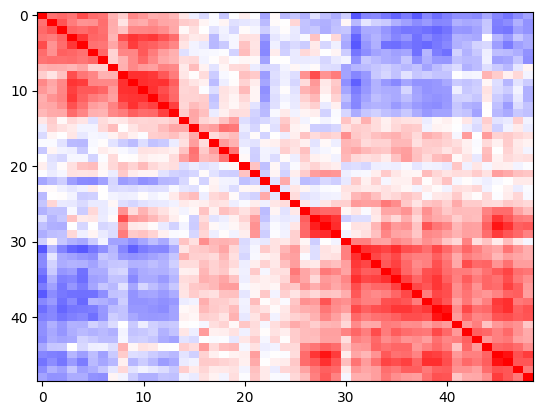

p-value range: 0.0076 - 0.9870
smallest value < p0.05: 0.6609537433442063
average value of significant correlations: 0.7487


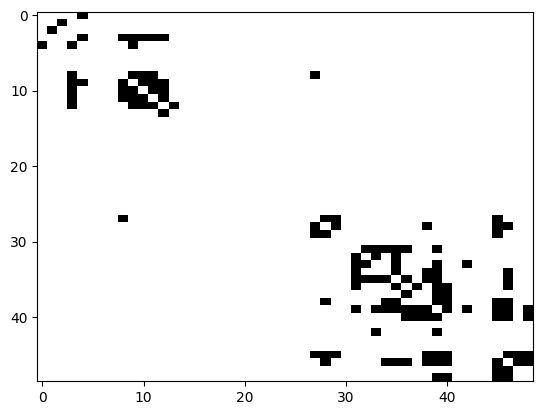


⚙️  Binarizing matrix using significance values...
✅ Weighted-network extraction complete. Network contains 70 valid edges

🔬 Starting network topology analysis...
✅ Network analysis completed. Key metrics:
Total_Nodes: 49
Total_Edges: 70
Total_Components: 22
Components_Lengths: [ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  2 27]
Max_Component_Size: 27

🔍 Selecting key cells in the network (top 10)...
          Key cell selection results
1. Top 10 hub cells by betweenness centrality:
 Cell_ID  Betweenness_Centrality  Degree
      27                  0.1356       4
       8                  0.1277       5
      45                  0.1193       9
      39                  0.0735      12
      46                  0.0320      10
       3                  0.0288       6
       9                  0.0288       6
      28                  0.0228       5
       4                  0.0222       3
      12                  0.0222       5

2. Top 10 high-degree cells:
 Cell_ID  Deg

C:\Users\Tony.S\AppData\Local\Temp\ipykernel_24376\1493202164.py:200: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


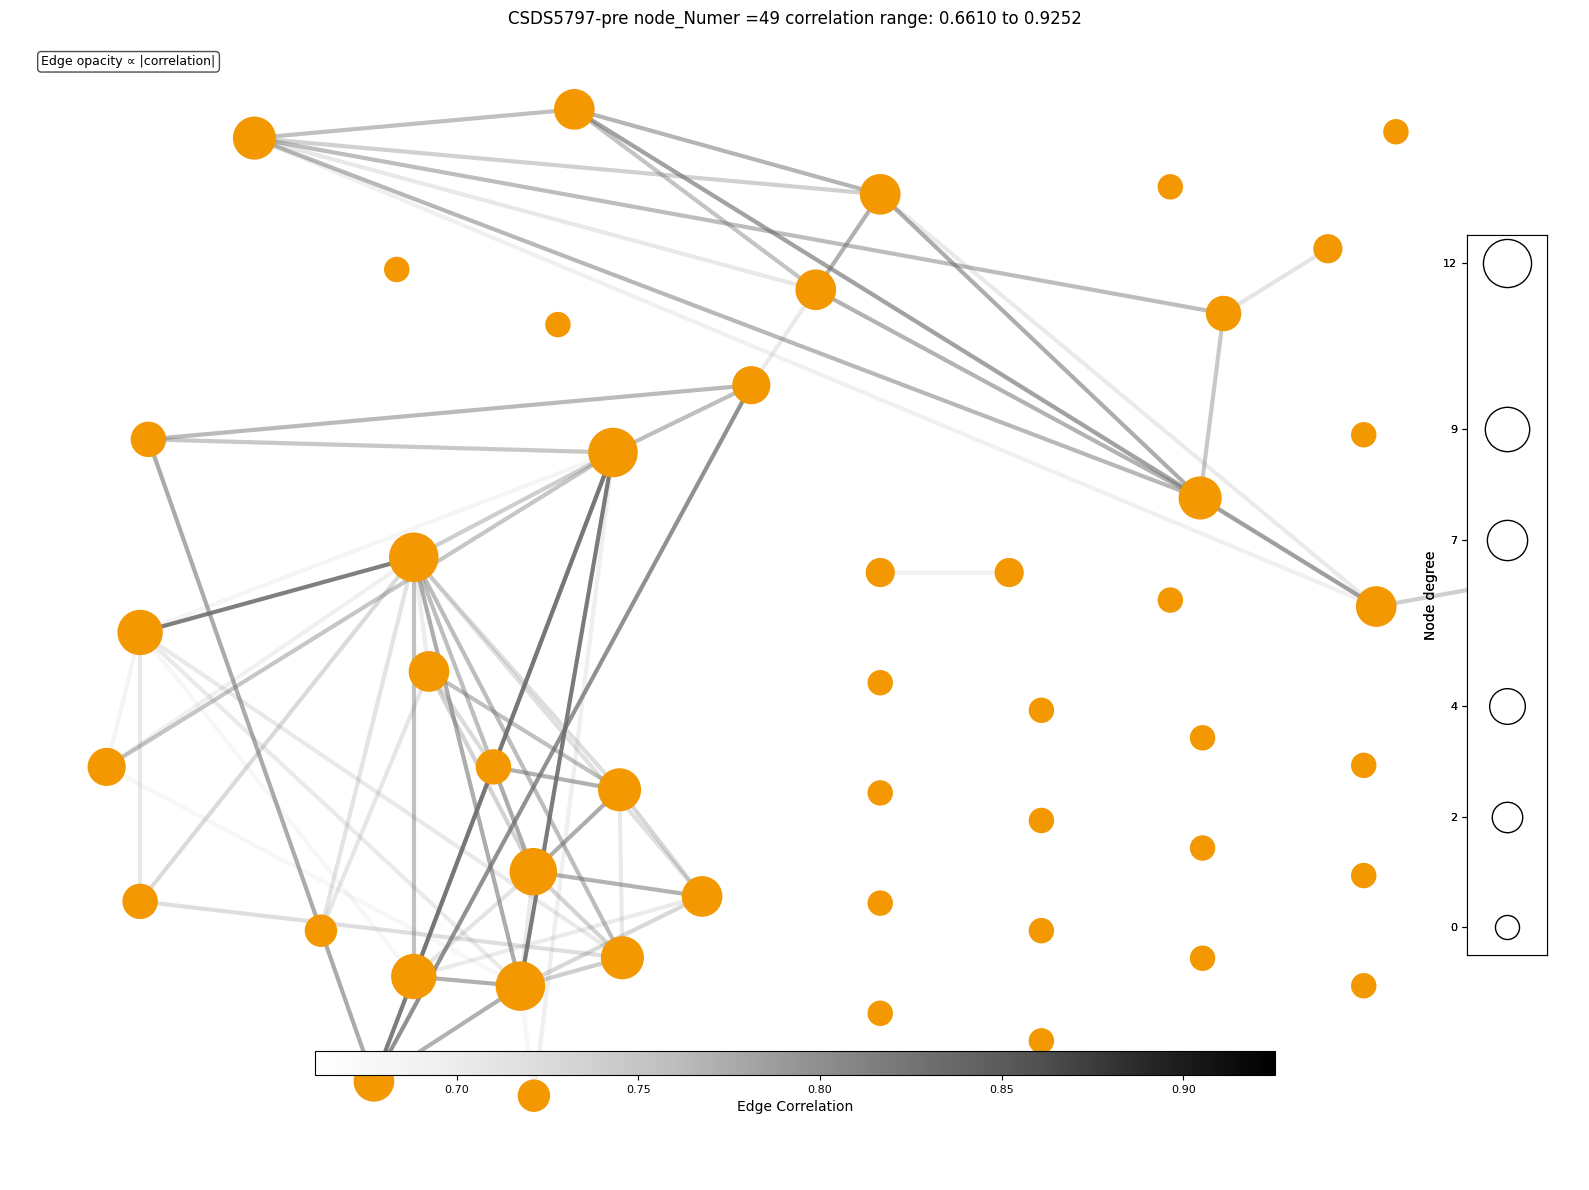


Processing condition: post with 1 samples

===== Processing sample: CSDS5797 - post =====
✅ Data loaded successfully: 25 cells, matrix shape 25x25


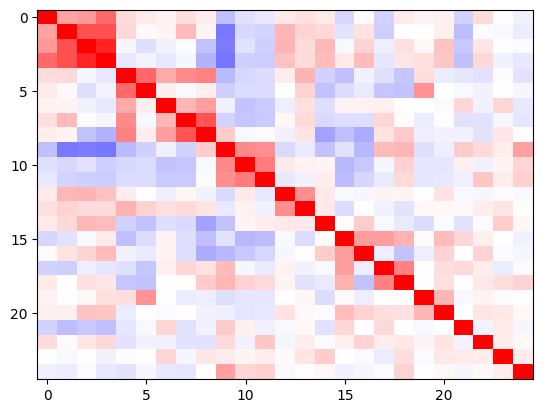

p-value range: 0.0000 - 0.9982
smallest value < p0.05: 0.3637063206828619
average value of significant correlations: 0.5030


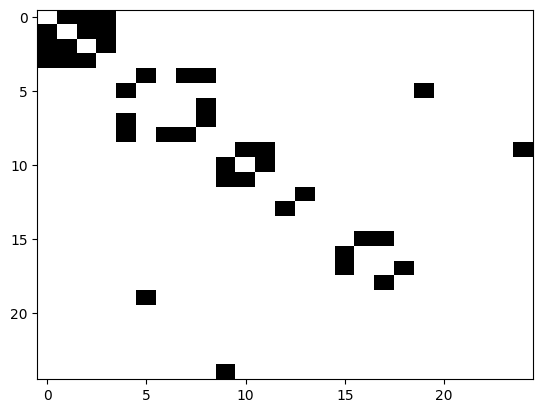


⚙️  Binarizing matrix using significance values...
✅ Weighted-network extraction complete. Network contains 20 valid edges

🔬 Starting network topology analysis...
✅ Network analysis completed. Key metrics:
Total_Nodes: 25
Total_Edges: 20
Total_Components: 10
Components_Lengths: [1 1 1 1 1 2 4 4 4 6]
Max_Component_Size: 6

🔍 Selecting key cells in the network (top 10)...
          Key cell selection results
1. Top 10 hub cells by betweenness centrality:
 Cell_ID  Betweenness_Centrality  Degree
       4                  0.0217       3
       5                  0.0145       2
       8                  0.0145       3
       9                  0.0072       3
      15                  0.0072       2
      17                  0.0072       2
       0                  0.0000       3
       1                  0.0000       3
       2                  0.0000       3
       3                  0.0000       3

2. Top 10 high-degree cells:
 Cell_ID  Degree  Clustering_Coefficient
       0       3   

C:\Users\Tony.S\AppData\Local\Temp\ipykernel_24376\1493202164.py:200: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


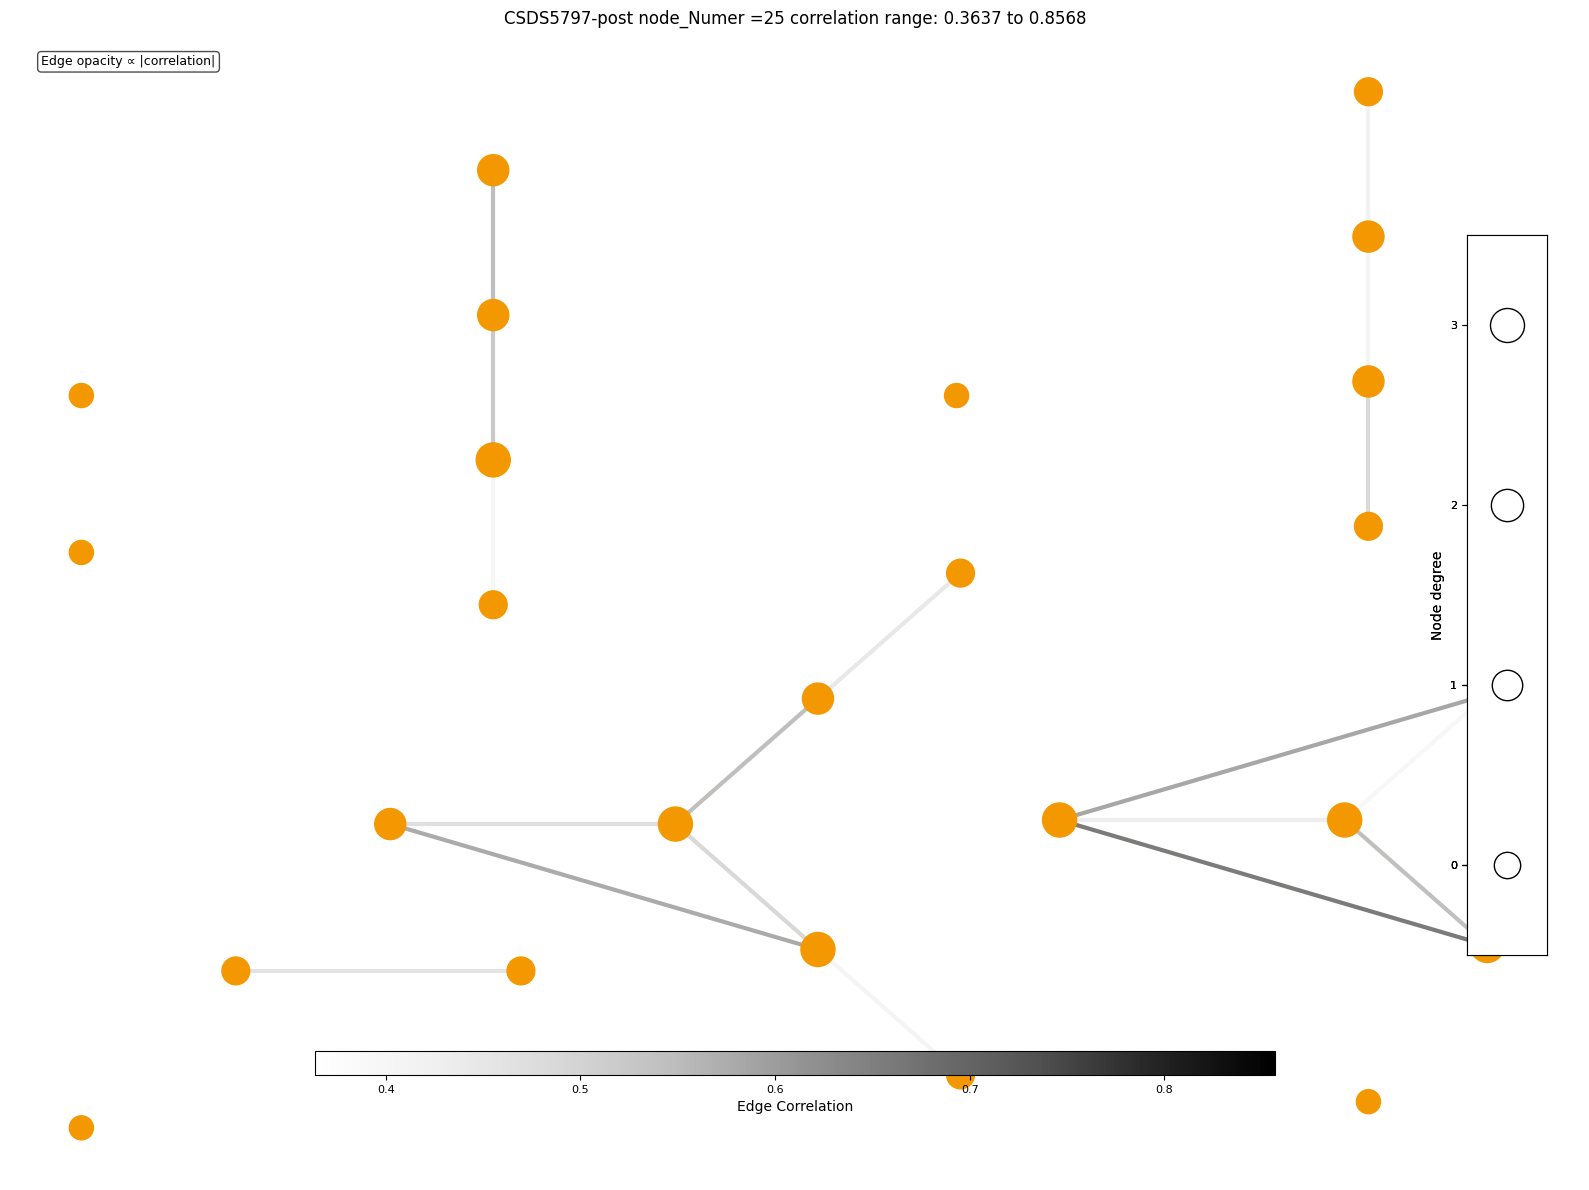


Processing condition: rescue with 1 samples

===== Processing sample: CSDS5797 - rescue =====
✅ Data loaded successfully: 51 cells, matrix shape 51x51


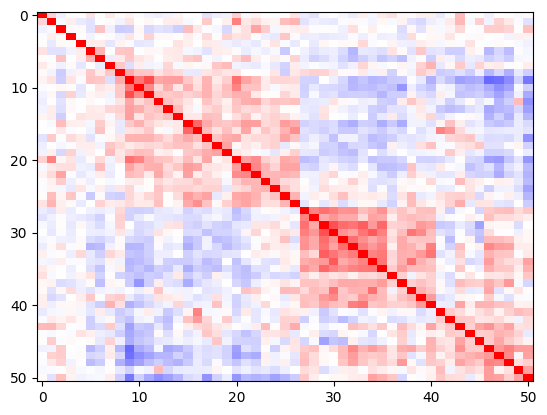

p-value range: 0.0002 - 0.9995
smallest value < p0.05: 0.3440657768465008
average value of significant correlations: 0.4445


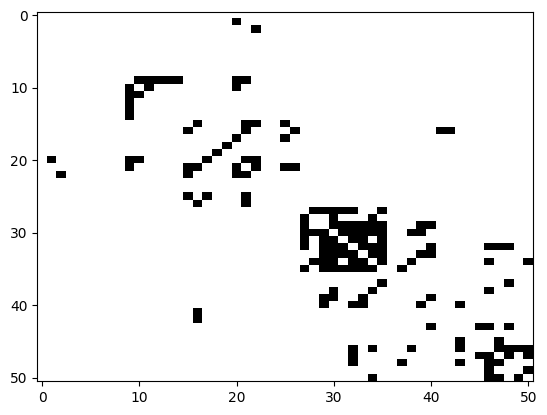


⚙️  Binarizing matrix using significance values...
✅ Weighted-network extraction complete. Network contains 84 valid edges

🔬 Starting network topology analysis...
✅ Network analysis completed. Key metrics:
Total_Nodes: 51
Total_Edges: 84
Total_Components: 14
Components_Lengths: [ 1  1  1  1  1  1  1  1  1  1  1  2 18 20]
Max_Component_Size: 20

🔍 Selecting key cells in the network (top 10)...
          Key cell selection results
1. Top 10 hub cells by betweenness centrality:
 Cell_ID  Betweenness_Centrality  Degree
      21                  0.0506       7
       9                  0.0473       7
      32                  0.0314      11
      20                  0.0303       6
      16                  0.0257       5
      46                  0.0226       8
      34                  0.0200       9
      22                  0.0141       4
      30                  0.0122      10
      47                  0.0105       5

2. Top 10 high-degree cells:
 Cell_ID  Degree  Clustering_Coeffici

C:\Users\Tony.S\AppData\Local\Temp\ipykernel_24376\1493202164.py:200: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


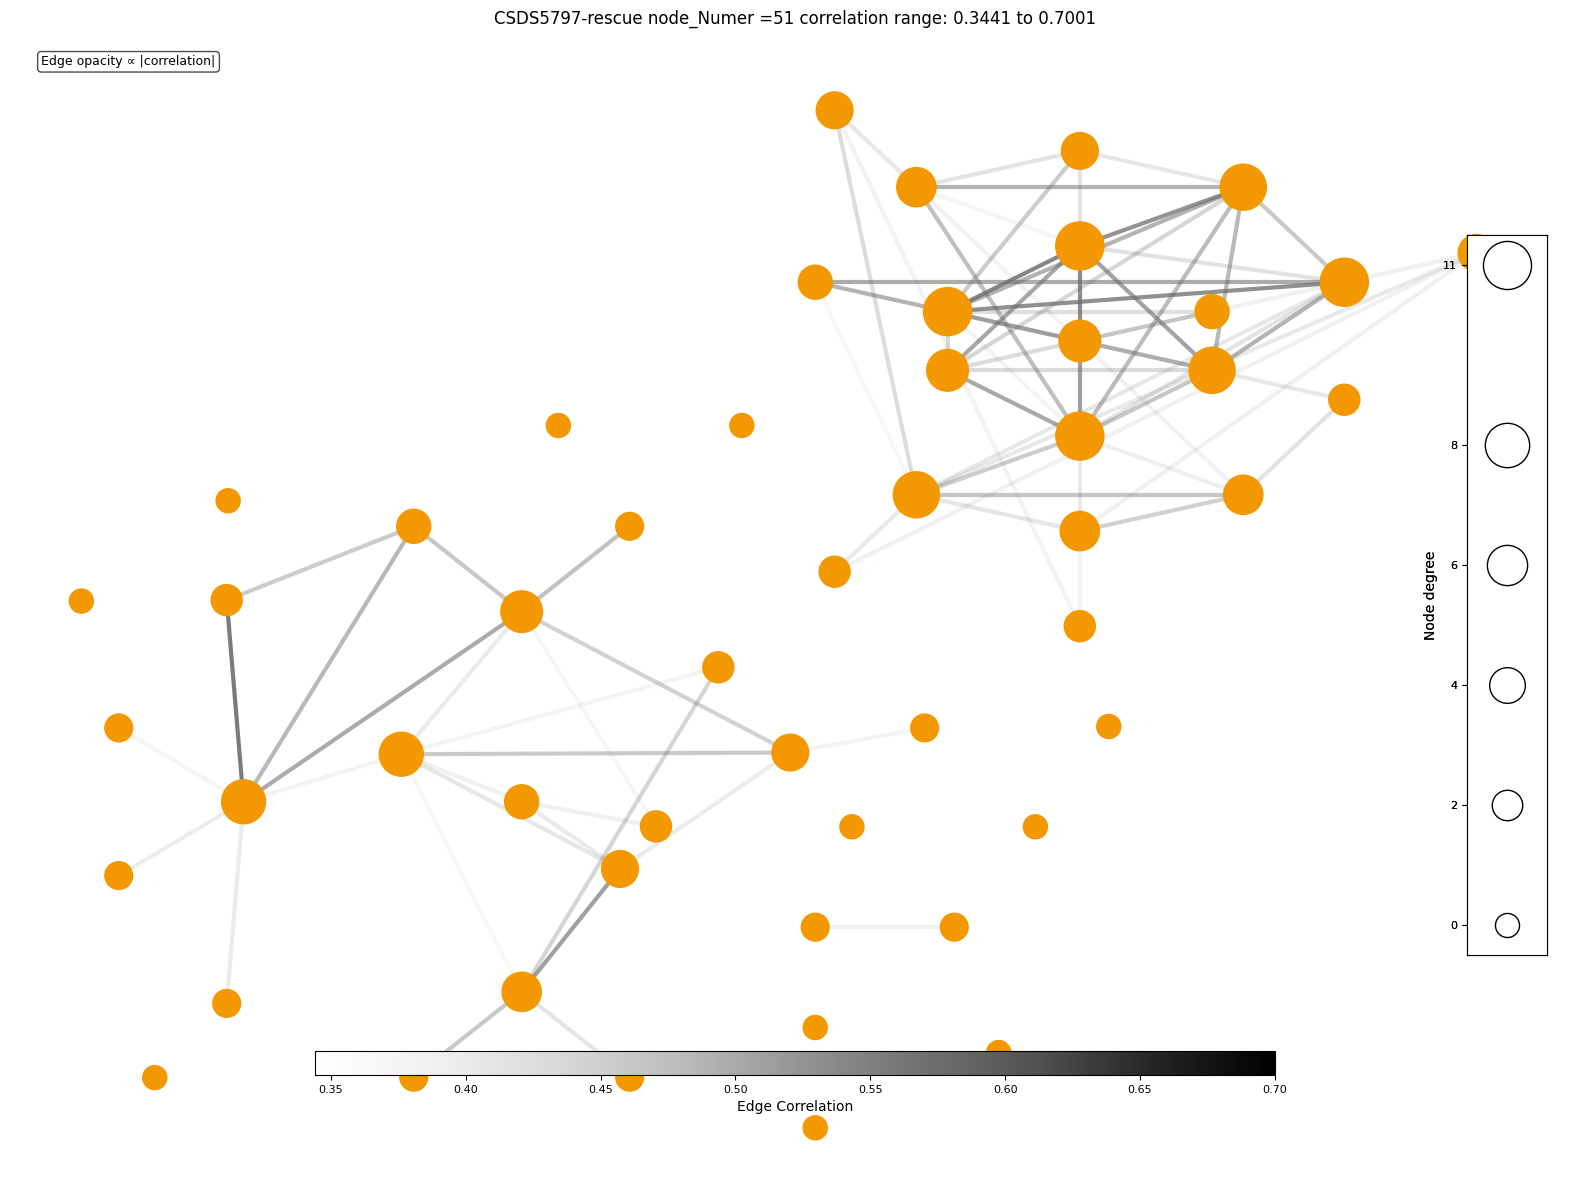

In [53]:

# Global parameters and path configuration
global VERBOSE
VERBOSE = True  # Whether to output detailed runtime logs
projectpath = 'G:\XJN_M2project'  # Project root path (replace with actual path)
conditions = ['pre', 'post', 'rescue']  # Experimental conditions ['pre', 'post', 'rescue']
test = 'test2'  # Test type

# %%
# Main loop (batch process samples and conditions)
for condition in conditions:
    condition_path = os.path.join(projectpath, "correlation_analysis", test, condition)
    IDs = [d for d in os.listdir(condition_path) if os.path.isdir(os.path.join(condition_path, d))]
    IDs = ['CSDS5797']
    print(f"\nProcessing condition: {condition} with {len(IDs)} samples")
    for miceID in IDs:
        # Input/output paths
        INPUT_FILE_PATH = os.path.join(projectpath, "correlation_analysis", test, condition, miceID, "correlation_TST.csv") # perason correaltion of neruons during TST
        if not os.path.exists(INPUT_FILE_PATH):
            print(f"WARNING: Input file not found: {INPUT_FILE_PATH}")
            continue
        OUTPUT_FILE_PATH = os.path.join(projectpath, "correlation_analysis", test, condition, miceID, "network_metrics_result_significance.csv")
        SHOW_VISUALIZATION = True  # Whether to display visualization plots

        # Plot settings (handle font rendering and minus sign display)
        plt.close('all')
        plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']
        plt.rcParams['axes.unicode_minus'] = False
        plt.rcParams['figure.dpi'] = 100

        # Data processing workflow
        print(f'\n===== Processing sample: {miceID} - {condition} =====')
        # 1. Data loading and validation
        data, cell_ids = load_and_validate_data(INPUT_FILE_PATH, test)
        Z = hierarchy.linkage(data, method='ward',metric='euclidean')
        order = hierarchy.dendrogram(Z, labels=data.columns)['leaves']
        plt.close()
        data_visual = data.iloc[order, order]
        plt.imshow(data_visual,aspect='auto',cmap='bwr',vmin=-1,vmax=1)
        plt.show()
        plt.close()
        data = data_visual
        # 2. Filtering (threshold=0.05)
        mask_2d, mask, avg_val, p_values = select_significant(data,0.05,None)
        if np.sum(np.array(mask))==0:
            print(f"WARNING: {miceID}-{condition} No data selected based on the threshold.")
            continue
        plt.imshow(mask_2d,aspect='auto',cmap='gray_r')
        plt.show()
        plt.close('all')
        
        # 3. Matrix binarization
        adjacency_matrix = weight_matrix(data.values, mask_2d)
        
        
        # 4. Network topology analysis
        G, node_df, network_df = analyze_network(adjacency_matrix, cell_ids)
        node_df['avg_correlation'] = avg_val
        # 5. Key-cell filtering
        betweenness_top10, degree_top10 = find_key_cells(node_df, top_n=10)
        
        # Output key-cell results
        print("="*60)
        print("          Key cell selection results")
        print("="*60)
        print(f"1. Top 10 hub cells by betweenness centrality:\n{betweenness_top10.to_string(index=False)}\n")
        print(f"2. Top 10 high-degree cells:\n{degree_top10.to_string(index=False)}")
        node_df.to_csv(OUTPUT_FILE_PATH, index=False, encoding="utf-8-sig")
        # 6. Visualize network
        if SHOW_VISUALIZATION:
            print(f'Plot network: {miceID}-{condition}')
            plot_network_visuals_new(G, np.sum(mask_2d)/2, node_df, degree_top10, data, is_save=False)


In [54]:
node_df

,Cell_ID,Clustering_Coefficient,Degree,Betweenness_Centrality,Component,Component_length,avg_correlation
0,0,0.000000,0,0.000000,0,1,0.444472
1,1,0.000000,1,0.000000,1,18,0.444472
2,2,0.000000,1,0.000000,1,18,0.444472
3,3,0.000000,0,0.000000,2,1,0.444472
4,4,0.000000,0,0.000000,3,1,0.444472
5,5,0.000000,0,0.000000,4,1,0.444472
6,6,0.000000,0,0.000000,5,1,0.444472
7,7,0.000000,0,0.000000,6,1,0.444472
8,8,0.000000,0,0.000000,7,1,0.444472
9,9,0.142857,7,0.047347,1,18,0.444472


In [55]:
node_df.to_csv(OUTPUT_FILE_PATH, index=False, encoding="utf-8-sig")